# K562 SEAM foregrounds + annotated seqlets

Auto-detects which single-seq SEAM foregrounds have finished (100k lib / 50 clusters)
and plots each `foreground_scaled.npy` logo with the hand-annotated seqlets overlaid.

Foregrounds are `(200, 4)` = the variable region, so annotation coords (`edits.csv`,
already in var-region space `[0, 200)`) map straight onto the x-axis — no adapter offset.

In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, logomaker
from pathlib import Path

FG_ROOT = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds')
SIT     = Path('/grid/koo/home/pmantill/projects/situate/data')

# annotated seqlets/motifs, keyed by situate row index (var-region coords [0,200))
ann = pd.read_csv(SIT / 'annotations/mcs_k562/edits.csv')

# peak name -> situate annotation row, parsed from names.txt (rows 0-2 are the peaks)
PEAK_TO_ANNROW = {}
for row, line in enumerate((SIT / 'mcs_k562/names.txt').read_text().splitlines()):
    tok = line.split()[0]
    if tok.startswith('peak'):
        PEAK_TO_ANNROW[tok] = row
PEAK_TO_ANNROW

{'peak26256': 0, 'peak84030': 1, 'peak27535_Reversed': 2}

In [8]:
# auto-detect finished foregrounds: dir must contain the final foreground_scaled.npy
finished = sorted(d.name for d in FG_ROOT.iterdir()
                  if d.is_dir() and (d / 'foreground_scaled.npy').exists())
print(f'{len(finished)} finished foreground(s):')
for p in finished:
    has = 'annotated' if p in PEAK_TO_ANNROW else 'NO annotations'
    print(f'  {p:24s} {has}')

3 finished foreground(s):
  peak26256                annotated
  peak27535_Reversed       annotated
  peak84030                annotated


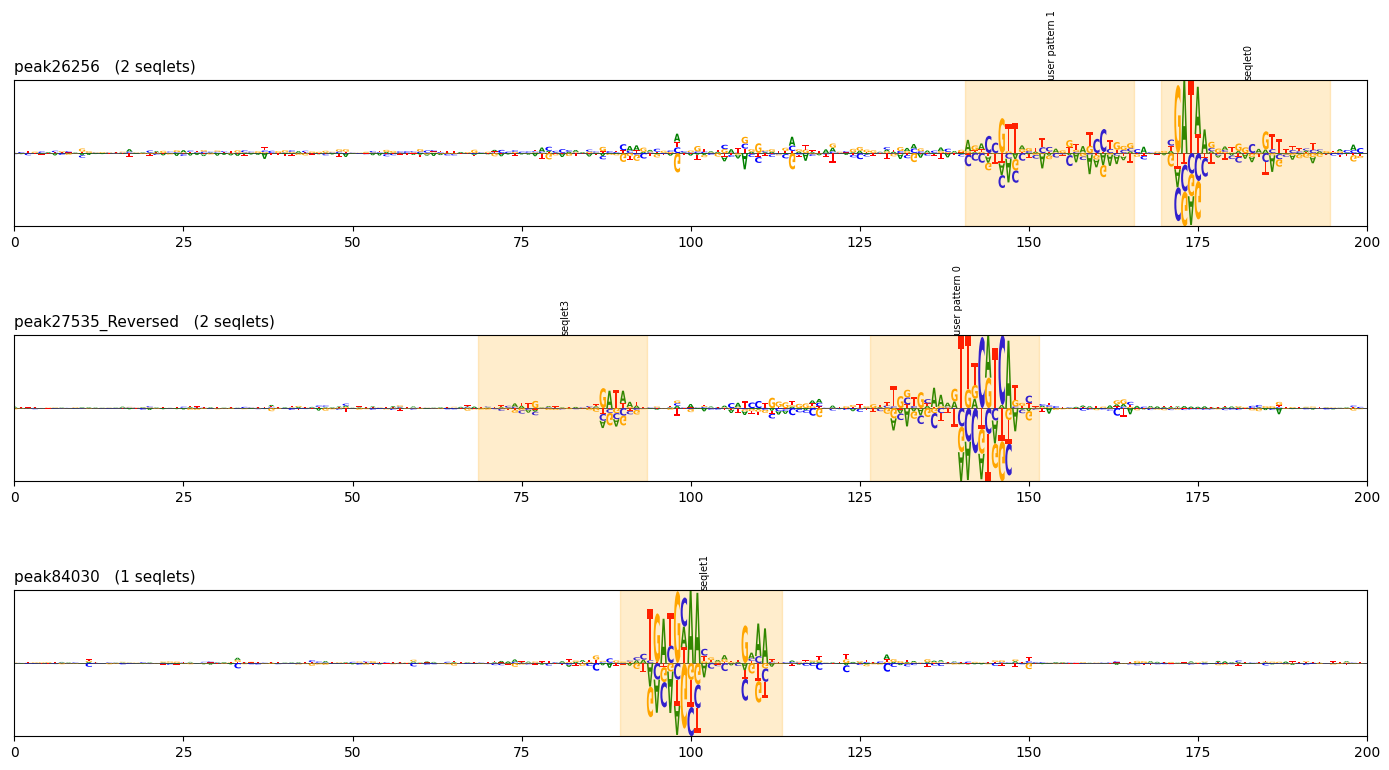

In [9]:
# one foreground logo per finished seq, annotated seqlets overlaid as labelled spans
fig, axes = plt.subplots(len(finished), 1, figsize=(14, 2.6 * len(finished)), squeeze=False)
for ax, peak in zip(axes[:, 0], finished):
    fg = np.load(FG_ROOT / peak / 'foreground_scaled.npy')          # (200, 4)
    logomaker.Logo(pd.DataFrame(fg, columns=list('ACGT')), ax=ax)   # raw 4-channel logo

    row = PEAK_TO_ANNROW.get(peak)
    seqlets = ann[ann.sequence_name == row] if row is not None else ann.iloc[0:0]
    for _, m in seqlets.iterrows():
        ax.axvspan(m.start - 0.5, m.end - 0.5, color='orange', alpha=0.2)
        ax.text((m.start + m.end) / 2, ax.get_ylim()[1], m.motif_name,
                ha='center', va='bottom', fontsize=7, rotation=90)

    tag = f'{len(seqlets)} seqlets' if row is not None else 'no annotations yet'
    ax.set_title(f'{peak}   ({tag})', loc='left', fontsize=11)
    ax.set_yticks([])
    ax.set_xlim(0, 200)
fig.tight_layout()

In [10]:
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/'
                   'Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src')
import h5py, torch
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

LIB   = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib')
N_REP = 30

CKPT = '/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt'
model = EncoderMPRAModel.from_checkpoint(CKPT, device='cuda').eval()
cfg = torch.load(CKPT, map_location='cpu', weights_only=False)['construct_config']
suffix = one_hot_encode(cfg['promoter_seq'] + cfg['barcode_seq']).float()  # (4,51) promoter+barcode

@torch.no_grad()
def predict_k562(insert_ohe):                       # (B,4,230) -> (B,) K562 pred
    x = torch.cat([insert_ohe, suffix.expand(len(insert_ohe), -1, -1)], 2)  # (B,4,281)
    return model(x.transpose(1, 2).cuda()).cpu().numpy()

ko_peaks = [p for p in finished if p in PEAK_TO_ANNROW]   # only seqs we have motif annotations for
print('context-KO on:', ko_peaks)

context-KO on: ['peak26256', 'peak27535_Reversed', 'peak84030']


In [11]:
# two KO conditions from the SAME 30 var-region shuffles; adapters always stay WT:
#   context KO -> variable-region context shuffled, annotated motifs kept  (context box)
#   motif KO   -> annotated motifs shuffled, rest of the sequence kept     (motif-syntax box)
wt_pred, ctxko_pred, motifko_pred = {}, {}, {}
for peak in ko_peaks:
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str  = f.attrs['wt_seq_str']
        ADAPTER = int(f.attrs['var_start'])          # variable region = insert[ADAPTER : ADAPTER+200]
    wt     = one_hot_encode(wt_str).float()                                          # (4,230)
    var    = slice(ADAPTER, ADAPTER + 200)
    shuf   = dinucleotide_shuffle(wt[:, var].unsqueeze(0), n=N_REP, random_state=0)[0]  # (30,4,200) var-region shuffles
    motifs = ann[ann.sequence_name == PEAK_TO_ANNROW[peak]]

    # context KO: replace whole variable region with shuffle, then paste motifs back
    ctx = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    ctx[:, :, var] = shuf
    for _, m in motifs.iterrows():
        ctx[:, :, m.start + ADAPTER : m.end + ADAPTER] = wt[:, m.start + ADAPTER : m.end + ADAPTER]

    # motif KO: keep WT everywhere, replace only the motif positions with the shuffle (shuf is var-indexed)
    mot = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    for _, m in motifs.iterrows():
        mot[:, :, m.start + ADAPTER : m.end + ADAPTER] = shuf[:, :, m.start : m.end]

    wt_pred[peak]      = float(predict_k562(wt.unsqueeze(0))[0])
    ctxko_pred[peak]   = predict_k562(ctx)     # (30,) one per replicate
    motifko_pred[peak] = predict_k562(mot)     # (30,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}   ctxKO={ctxko_pred[peak].mean():+.3f}   motifKO={motifko_pred[peak].mean():+.3f}')

peak26256                WT=+1.732   ctxKO=+1.272   motifKO=-0.487
peak27535_Reversed       WT=+1.765   ctxKO=+0.497   motifKO=-0.460
peak84030                WT=+1.795   ctxKO=+0.734   motifKO=-0.062


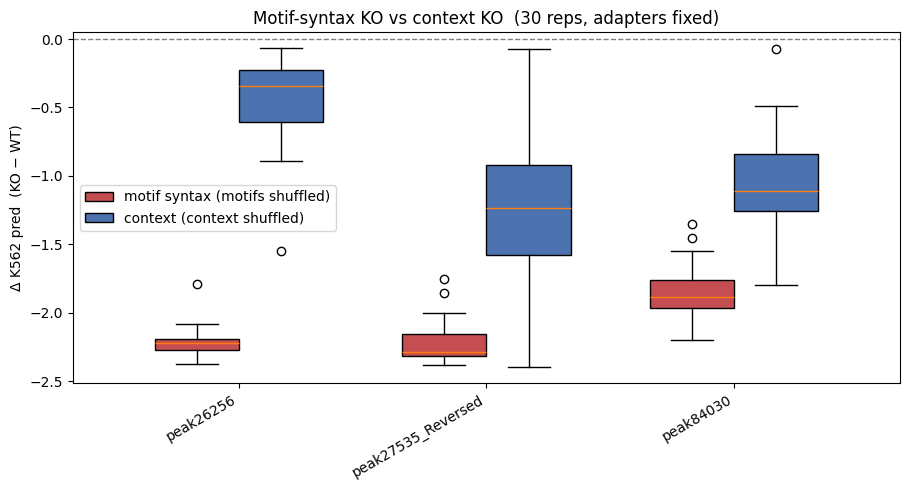

In [12]:
# delta = KO - WT prediction (per replicate); two boxes per seq: motif-syntax KO vs context KO
w = 0.34
xg = np.arange(len(ko_peaks))
d_mot = [motifko_pred[p] - wt_pred[p] for p in ko_peaks]   # motif-syntax box: motifs shuffled, context kept
d_ctx = [ctxko_pred[p]  - wt_pred[p] for p in ko_peaks]    # context box: context shuffled, motifs kept

fig, ax = plt.subplots(figsize=(2.4 * len(ko_peaks) + 2, 5))
b_mot = ax.boxplot(d_mot, positions=xg - w/2, widths=w, patch_artist=True)
b_ctx = ax.boxplot(d_ctx, positions=xg + w/2, widths=w, patch_artist=True)
for b in b_mot['boxes']: b.set_facecolor('#c44e52')
for b in b_ctx['boxes']: b.set_facecolor('#4c72b0')
ax.axhline(0, color='0.5', lw=1, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('Δ K562 pred  (KO − WT)')
ax.set_title(f'Motif-syntax KO vs context KO  ({N_REP} reps, adapters fixed)')
ax.legend([b_mot['boxes'][0], b_ctx['boxes'][0]],
          ['motif syntax (motifs shuffled)', 'context (context shuffled)'])
fig.tight_layout()